<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da08_gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임 생성

gapminder 데이터 분석

In [2]:
file_path = 'https://raw.githubusercontent.com/JakeOh/202605_BD57/refs/heads/main/datasets/gapminder.tsv'

In [3]:
gapminder = pd.read_csv(file_path, sep='\t')

In [4]:
gapminder.head(n=6)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
5,Afghanistan,Asia,1977,38.438,14880372,786.113360


In [5]:
gapminder.tail(n=6)

,country,continent,year,lifeExp,pop,gdpPercap
1698,Zimbabwe,Africa,1982,60.363,7636524,788.855041
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298


In [6]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


# 기술 통계량

## 연속형 변수

In [7]:
gapminder.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


## 범주형(카테고리) 변수

In [9]:
# 나라 이름들
countries = gapminder.country.unique()
countries

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

In [10]:
len(countries)

142

In [11]:
gapminder.country.value_counts()

,count
country,
Afghanistan,12
Albania,12
Algeria,12
Angola,12
Argentina,12
...,...
Vietnam,12
West Bank and Gaza,12
"Yemen, Rep.",12


In [12]:
# 대륙 이름들
continents = gapminder.continent.unique()
continents

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

In [13]:
gapminder.continent.value_counts()

,count
continent,
Africa,624
Asia,396
Europe,360
Americas,300
Oceania,24


In [15]:
# 연도
years = gapminder.year.unique()
years

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [16]:
gapminder.year.value_counts()

,count
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


# 기대수명(lifeExp) 분석

In [18]:
gapminder.lifeExp.describe()

,lifeExp
count,1704.000000
mean,59.474439
std,12.917107
min,23.599000
25%,48.198000
50%,60.712500
75%,70.845500
max,82.603000


In [19]:
# 기대수명이 최솟값인 행
gapminder[gapminder.lifeExp == gapminder.lifeExp.min()]

,country,continent,year,lifeExp,pop,gdpPercap
1292,Rwanda,Africa,1992,23.599,7290203,737.068595


In [20]:
# 기대수명이 최댓값인 행
gapminder[gapminder.lifeExp == gapminder.lifeExp.max()]

,country,continent,year,lifeExp,pop,gdpPercap
803,Japan,Asia,2007,82.603,127467972,31656.06806


## 일본 기대수명

In [21]:
japan_df = gapminder[gapminder.country == 'Japan']
japan_df

,country,continent,year,lifeExp,pop,gdpPercap
792,Japan,Asia,1952,63.030,86459025,3216.956347
793,Japan,Asia,1957,65.500,91563009,4317.694365
794,Japan,Asia,1962,68.730,95831757,6576.649461
795,Japan,Asia,1967,71.430,100825279,9847.788607
796,Japan,Asia,1972,73.420,107188273,14778.786360
797,Japan,Asia,1977,75.380,113872473,16610.377010
798,Japan,Asia,1982,77.110,118454974,19384.105710
799,Japan,Asia,1987,78.670,122091325,22375.941890
800,Japan,Asia,1992,79.360,124329269,26824.895110
801,Japan,Asia,1997,80.690,125956499,28816.584990


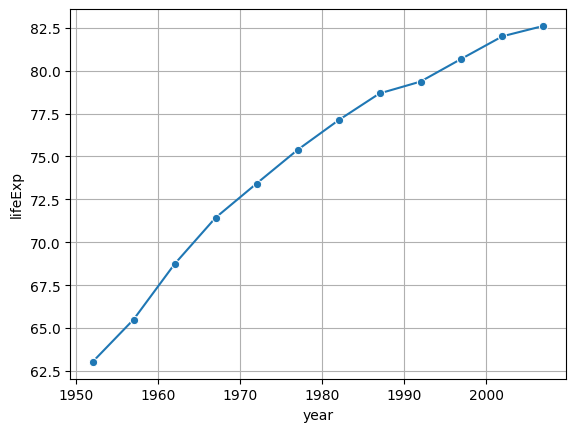

In [23]:
# 일본 기대수명 시계열 그래프
sns.lineplot(data=japan_df, x='year', y='lifeExp', marker='o')
plt.grid()
plt.show()

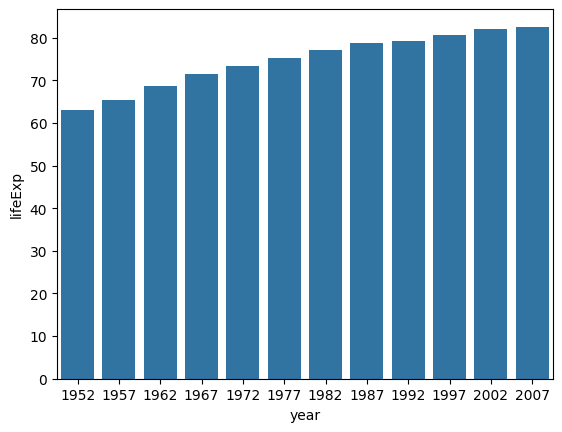

In [24]:
sns.barplot(data=japan_df, x='year', y='lifeExp', errorbar=None)
plt.show()

## 르완다 기대수명

In [25]:
rwanda_df = gapminder[gapminder.country == 'Rwanda']
rwanda_df

,country,continent,year,lifeExp,pop,gdpPercap
1284,Rwanda,Africa,1952,40.000,2534927,493.323875
1285,Rwanda,Africa,1957,41.500,2822082,540.289398
1286,Rwanda,Africa,1962,43.000,3051242,597.473073
1287,Rwanda,Africa,1967,44.100,3451079,510.963714
1288,Rwanda,Africa,1972,44.600,3992121,590.580664
1289,Rwanda,Africa,1977,45.000,4657072,670.080601
1290,Rwanda,Africa,1982,46.218,5507565,881.570647
1291,Rwanda,Africa,1987,44.020,6349365,847.991217
1292,Rwanda,Africa,1992,23.599,7290203,737.068595
1293,Rwanda,Africa,1997,36.087,7212583,589.944505


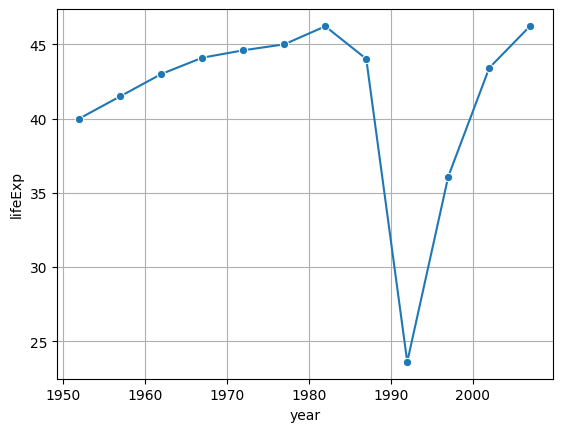

In [26]:
sns.lineplot(data=rwanda_df, x='year', y='lifeExp', marker='o')
plt.grid()
plt.show()

## 연도별 기대수명 변화

In [27]:
# 연도별 기대수명 평균
gapminder.groupby(by='year').lifeExp.mean()

,lifeExp
year,
1952,49.057620
1957,51.507401
1962,53.609249
1967,55.678290
1972,57.647386
1977,59.570157
1982,61.533197
1987,63.212613
1992,64.160338


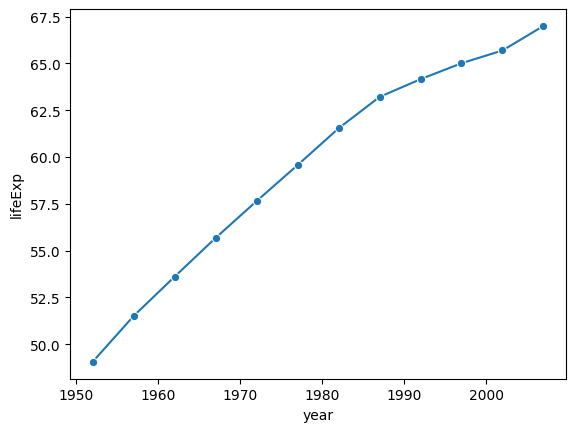

In [30]:
sns.lineplot(data=gapminder, x='year', y='lifeExp', estimator='mean',
             marker='o', errorbar=None)
plt.show()

## 연도별 대륙별 기대수명 변환

In [31]:
# 연도별 대륙별 기대수명 평균
gapminder.groupby(by=['year', 'continent']).lifeExp.mean()

year  continent
1952  Africa       39.135500
      Americas     53.279840
      Asia         46.314394
      Europe       64.408500
      Oceania      69.255000
1957  Africa       41.266346
      Americas     55.960280
      Asia         49.318544
      Europe       66.703067
      Oceania      70.295000
1962  Africa       43.319442
      Americas     58.398760
      Asia         51.563223
      Europe       68.539233
      Oceania      71.085000
1967  Africa       45.334538
      Americas     60.410920
      Asia         54.663640
      Europe       69.737600
      Oceania      71.310000
1972  Africa       47.450942
      Americas     62.394920
      Asia         57.319269
      Europe       70.775033
      Oceania      71.910000
1977  Africa       49.580423
      Americas     64.391560
      Asia         59.610556
      Europe       71.937767
      Oceania      72.855000
1982  Africa       51.592865
      Americas     66.228840
      Asia         62.617939
      Europe       72.806400
      Oceania      74.290000
1987  Africa       53.344788
      Americas     68.090720
      Asia         64.851182
      Europe       73.642167
      Oceania      75.320000
1992  Africa       53.629577
      Americas     69.568360
      Asia         66.537212
      Europe       74.440100
      Oceania      76.945000
1997  Africa       53.598269
      Americas     71.150480
      Asia         68.020515
      Europe       75.505167
      Oceania      78.190000
2002  Africa       53.325231
      Americas     72.422040
      Asia         69.233879
      Europe       76.700600
      Oceania      79.740000
2007  Africa       54.806038
      Americas     73.608120
      Asia         70.728485
      Europe       77.648600
      Oceania      80.719500
Name: lifeExp, dtype: float64

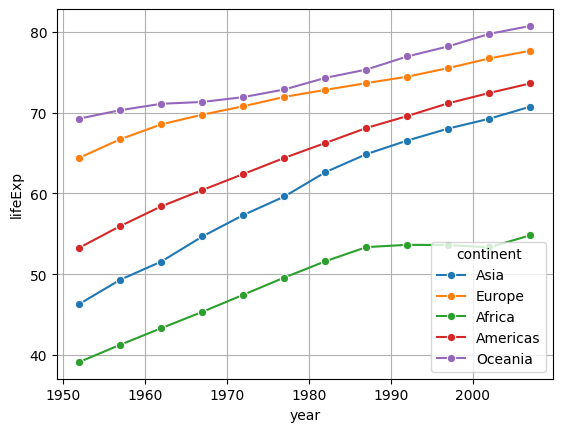

In [35]:
sns.lineplot(data=gapminder, x='year', y='lifeExp', hue='continent', errorbar=None, marker='o')
plt.grid()
plt.show()

# 인구(pop) 분석

In [36]:
# 인구가 최댓값인 행
gapminder[gapminder['pop'] == gapminder['pop'].max()]

,country,continent,year,lifeExp,pop,gdpPercap
299,China,Asia,2007,72.961,1318683096,4959.114854


In [37]:
# 인구가 최솟값인 행
gapminder[gapminder['pop'] == gapminder['pop'].min()]

,country,continent,year,lifeExp,pop,gdpPercap
1296,Sao Tome and Principe,Africa,1952,46.471,60011,879.583586


## 대륙별 인구 변화

In [39]:
# 연도별 대륙별 인구 합계
gapminder.groupby(by=['year', 'continent'])['pop'].sum()

year  continent
1952  Africa        237640501
      Americas      345152446
      Asia         1395357351
      Europe        418120846
      Oceania        10686006
1957  Africa        264837738
      Americas      386953916
      Asia         1562780599
      Europe        437890351
      Oceania        11941976
1962  Africa        296516865
      Americas      433270254
      Asia         1696357182
      Europe        460355155
      Oceania        13283518
1967  Africa        335289489
      Americas      480746623
      Asia         1905662900
      Europe        481178958
      Oceania        14600414
1972  Africa        379879541
      Americas      529384210
      Asia         2150972248
      Europe        500635059
      Oceania        16106100
1977  Africa        433061021
      Americas      578067699
      Asia         2384513556
      Europe        517164531
      Oceania        17239000
1982  Africa        499348587
      Americas      630290920
      Asia         2610135582
      Europe        531266901
      Oceania        18394850
1987  Africa        574834110
      Americas      682753971
      Asia         2871220762
      Europe        543094160
      Oceania        19574415
1992  Africa        659081517
      Americas      739274104
      Asia         3133292191
      Europe        558142797
      Oceania        20919651
1997  Africa        743832984
      Americas      796900410
      Asia         3383285500
      Europe        568944148
      Oceania        22241430
2002  Africa        833723916
      Americas      849772762
      Asia         3601802203
      Europe        578223869
      Oceania        23454829
2007  Africa        929539692
      Americas      898871184
      Asia         3811953827
      Europe        586098529
      Oceania        24549947
Name: pop, dtype: int64

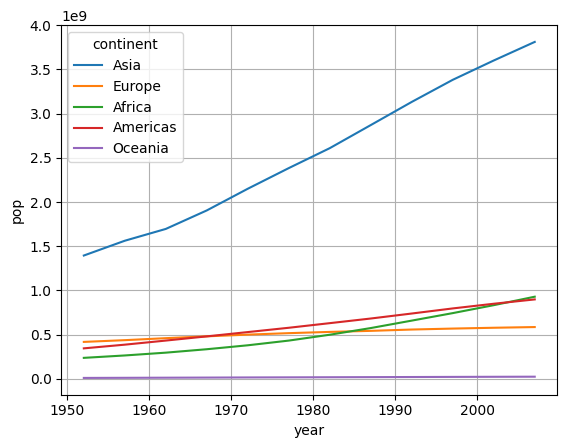

In [42]:
sns.lineplot(data=gapminder, x='year', y='pop', hue='continent', estimator='sum',
             errorbar=None)
plt.grid()
plt.show()

## 아시아 대륙을 제외한 4개 대륙의 인구 변화

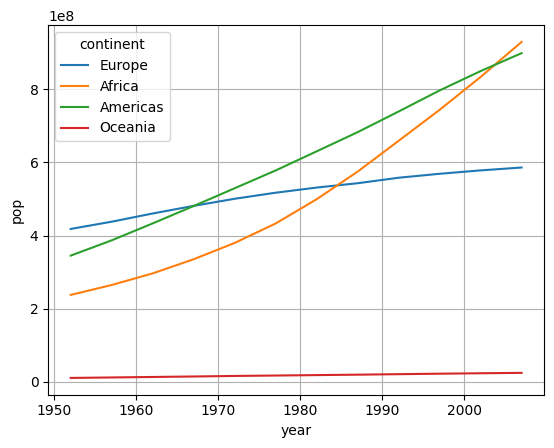

In [43]:
sns.lineplot(data=gapminder[gapminder.continent != 'Asia'],
             x='year', y='pop', hue='continent',
             estimator='sum', errorbar=None)
plt.grid()
plt.show()

# 1인당 GDP(gdpPercap) 분석

In [44]:
# gdpPercap이 최댓값인 행
gapminder[gapminder.gdpPercap == gapminder.gdpPercap.max()]

,country,continent,year,lifeExp,pop,gdpPercap
853,Kuwait,Asia,1957,58.033,212846,113523.1329


In [45]:
# gdpPercap이 최솟값인 행
gapminder[gapminder.gdpPercap == gapminder.gdpPercap.min()]

,country,continent,year,lifeExp,pop,gdpPercap
334,"Congo, Dem. Rep.",Africa,2002,44.966,55379852,241.165876


## 쿠웨이트 1인당 GDP 변화

In [46]:
kuwait_df = gapminder[gapminder.country == 'Kuwait']
kuwait_df

,country,continent,year,lifeExp,pop,gdpPercap
852,Kuwait,Asia,1952,55.565,160000,108382.35290
853,Kuwait,Asia,1957,58.033,212846,113523.13290
854,Kuwait,Asia,1962,60.470,358266,95458.11176
855,Kuwait,Asia,1967,64.624,575003,80894.88326
856,Kuwait,Asia,1972,67.712,841934,109347.86700
857,Kuwait,Asia,1977,69.343,1140357,59265.47714
858,Kuwait,Asia,1982,71.309,1497494,31354.03573
859,Kuwait,Asia,1987,74.174,1891487,28118.42998
860,Kuwait,Asia,1992,75.190,1418095,34932.91959
861,Kuwait,Asia,1997,76.156,1765345,40300.61996


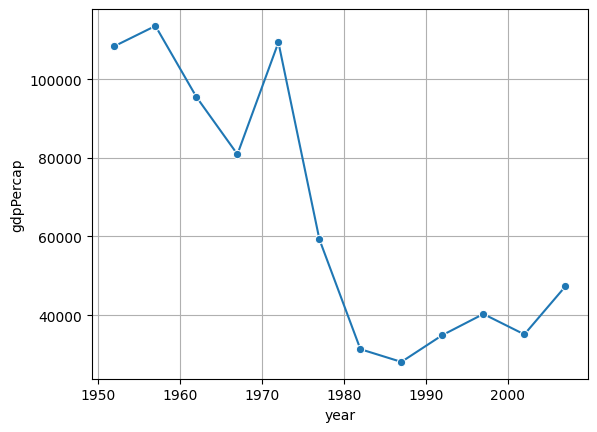

In [47]:
sns.lineplot(data=kuwait_df, x='year', y='gdpPercap', marker='o')
plt.grid()
plt.show()

## 콩고 1인당 GDP 변화

In [48]:
congo_df = gapminder[gapminder.country == 'Congo, Dem. Rep.']
congo_df

,country,continent,year,lifeExp,pop,gdpPercap
324,"Congo, Dem. Rep.",Africa,1952,39.143,14100005,780.542326
325,"Congo, Dem. Rep.",Africa,1957,40.652,15577932,905.860230
326,"Congo, Dem. Rep.",Africa,1962,42.122,17486434,896.314634
327,"Congo, Dem. Rep.",Africa,1967,44.056,19941073,861.593242
328,"Congo, Dem. Rep.",Africa,1972,45.989,23007669,904.896068
329,"Congo, Dem. Rep.",Africa,1977,47.804,26480870,795.757282
330,"Congo, Dem. Rep.",Africa,1982,47.784,30646495,673.747818
331,"Congo, Dem. Rep.",Africa,1987,47.412,35481645,672.774812
332,"Congo, Dem. Rep.",Africa,1992,45.548,41672143,457.719181
333,"Congo, Dem. Rep.",Africa,1997,42.587,47798986,312.188423


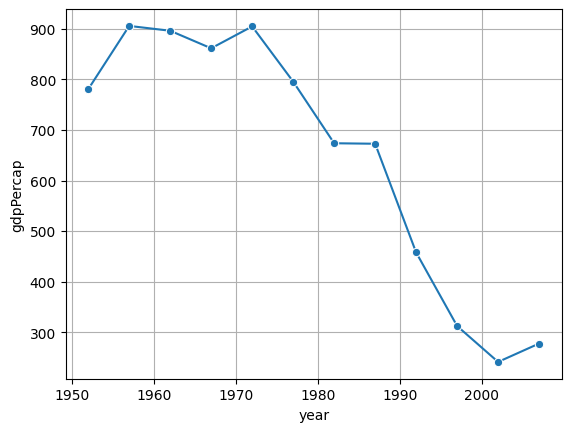

In [49]:
sns.lineplot(data=congo_df, x='year', y='gdpPercap', marker='o')
plt.grid()
plt.show()

## 대륙별 1인당 GDP 평균 변화

In [50]:
# 연도별 대륙별 1인당 GDP 평균
gapminder.groupby(by=['year', 'continent']).gdpPercap.mean()

year  continent
1952  Africa        1252.572466
      Americas      4079.062552
      Asia          5195.484004
      Europe        5661.057435
      Oceania      10298.085650
1957  Africa        1385.236062
      Americas      4616.043733
      Asia          5787.732940
      Europe        6963.012816
      Oceania      11598.522455
1962  Africa        1598.078825
      Americas      4901.541870
      Asia          5729.369625
      Europe        8365.486814
      Oceania      12696.452430
1967  Africa        2050.363801
      Americas      5668.253496
      Asia          5971.173374
      Europe       10143.823757
      Oceania      14495.021790
1972  Africa        2339.615674
      Americas      6491.334139
      Asia          8187.468699
      Europe       12479.575246
      Oceania      16417.333380
1977  Africa        2585.938508
      Americas      7352.007126
      Asia          7791.314020
      Europe       14283.979110
      Oceania      17283.957605
1982  Africa        2481.592960
      Americas      7506.737088
      Asia          7434.135157
      Europe       15617.896551
      Oceania      18554.709840
1987  Africa        2282.668991
      Americas      7793.400261
      Asia          7608.226508
      Europe       17214.310727
      Oceania      20448.040160
1992  Africa        2281.810333
      Americas      8044.934406
      Asia          8639.690248
      Europe       17061.568084
      Oceania      20894.045885
1997  Africa        2378.759555
      Americas      8889.300863
      Asia          9834.093295
      Europe       19076.781802
      Oceania      24024.175170
2002  Africa        2599.385159
      Americas      9287.677107
      Asia         10174.090397
      Europe       21711.732422
      Oceania      26938.778040
2007  Africa        3089.032605
      Americas     11003.031625
      Asia         12473.026870
      Europe       25054.481636
      Oceania      29810.188275
Name: gdpPercap, dtype: float64

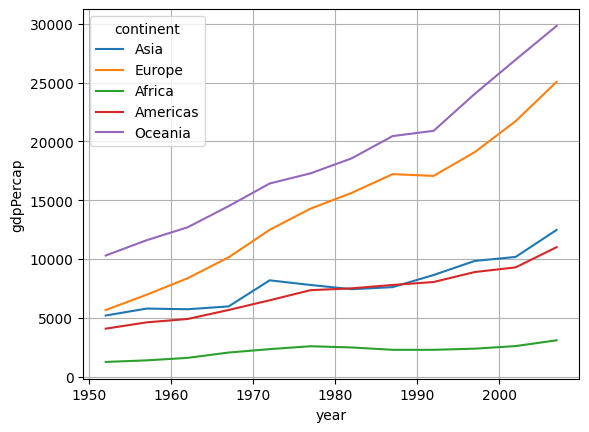

In [51]:
sns.lineplot(data=gapminder, x='year', y='gdpPercap', hue='continent', errorbar=None)
plt.grid()
plt.show()

## 2007년 1인당 GDP 상위 10개 국가

In [56]:
gdp_top10 = gapminder[gapminder.year == 2007].sort_values(by='gdpPercap', ascending=False).head(n=10)
gdp_top10

,country,continent,year,lifeExp,pop,gdpPercap
1151,Norway,Europe,2007,80.196,4627926,49357.19017
863,Kuwait,Asia,2007,77.588,2505559,47306.98978
1367,Singapore,Asia,2007,79.972,4553009,47143.17964
1619,United States,Americas,2007,78.242,301139947,42951.65309
755,Ireland,Europe,2007,78.885,4109086,40675.99635
671,"Hong Kong, China",Asia,2007,82.208,6980412,39724.97867
1487,Switzerland,Europe,2007,81.701,7554661,37506.41907
1091,Netherlands,Europe,2007,79.762,16570613,36797.93332
251,Canada,Americas,2007,80.653,33390141,36319.23501
695,Iceland,Europe,2007,81.757,301931,36180.78919


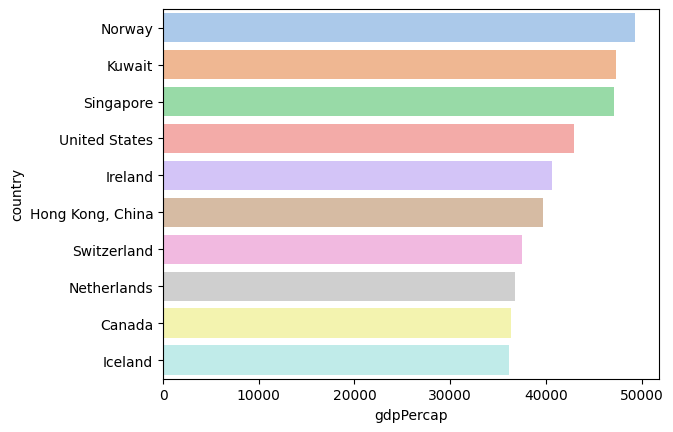

In [59]:
sns.barplot(data=gdp_top10, x='gdpPercap', y='country', hue='country', palette='pastel')
plt.show()

## 2007년 1인당 GDP 하위 10개 국가

In [64]:
gdp_bottom10 = gapminder[gapminder.year == 2007].sort_values(by='gdpPercap').head(n=10)
gdp_bottom10

,country,continent,year,lifeExp,pop,gdpPercap
335,"Congo, Dem. Rep.",Africa,2007,46.462,64606759,277.551859
899,Liberia,Africa,2007,45.678,3193942,414.507341
215,Burundi,Africa,2007,49.580,8390505,430.070692
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298
635,Guinea-Bissau,Africa,2007,46.388,1472041,579.231743
1127,Niger,Africa,2007,56.867,12894865,619.676892
503,Eritrea,Africa,2007,58.040,4906585,641.369524
515,Ethiopia,Africa,2007,52.947,76511887,690.805576
263,Central African Republic,Africa,2007,44.741,4369038,706.016537
563,Gambia,Africa,2007,59.448,1688359,752.749726


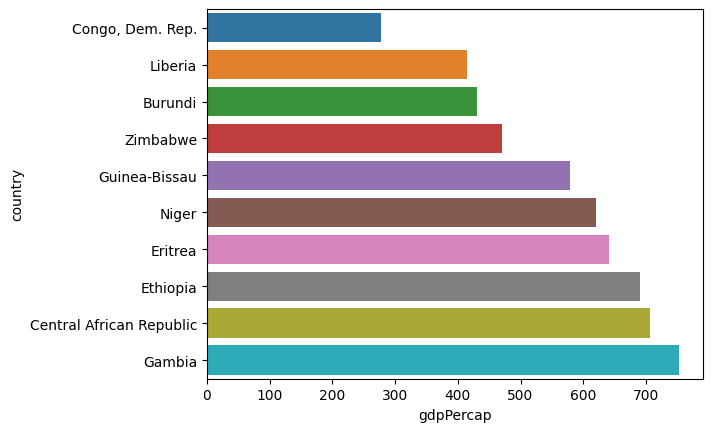

In [65]:
sns.barplot(data=gdp_bottom10, x='gdpPercap', y='country', hue='country')
plt.show()

## 한국, 일본, 중국의 1인당 GDP 변화

In [73]:
# cjk_df = gapminder[(gapminder.country == 'Korea, Rep.') |
#                    (gapminder.country == 'China') |
#                    (gapminder.country == 'Japan')]

cjk = [ 'China', 'Japan', 'Korea, Rep.' ]
cjk_df = gapminder[gapminder.country.isin(cjk)]

cjk_df

,country,continent,year,lifeExp,pop,gdpPercap
288,China,Asia,1952,44.00000,556263527,400.448611
289,China,Asia,1957,50.54896,637408000,575.987001
290,China,Asia,1962,44.50136,665770000,487.674018
291,China,Asia,1967,58.38112,754550000,612.705693
292,China,Asia,1972,63.11888,862030000,676.900092
293,China,Asia,1977,63.96736,943455000,741.237470
294,China,Asia,1982,65.52500,1000281000,962.421381
295,China,Asia,1987,67.27400,1084035000,1378.904018
296,China,Asia,1992,68.69000,1164970000,1655.784158
297,China,Asia,1997,70.42600,1230075000,2289.234136


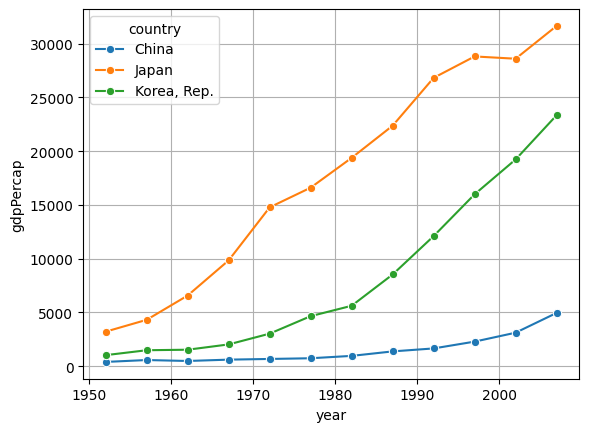

In [74]:
sns.lineplot(data=cjk_df, x='year', y='gdpPercap', hue='country', marker='o')
plt.grid()
plt.show()

# 이중축 차트

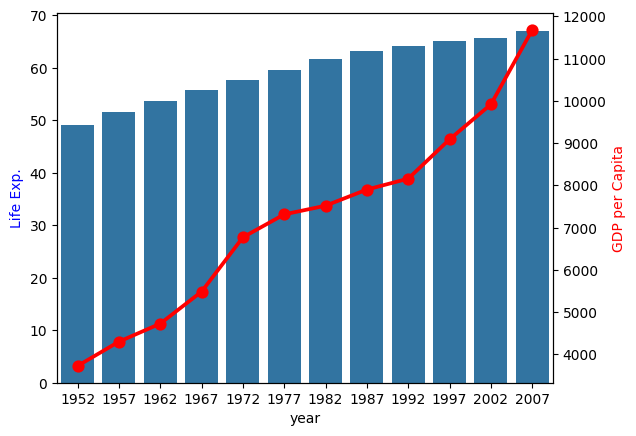

In [85]:
fig, ax1 = plt.subplots()

# 연도별 기대수명 평균 막대 그래프를 ax1에 시각화
sns.barplot(data=gapminder, x='year', y='lifeExp', errorbar=None, ax=ax1)
ax1.set_ylabel('Life Exp.', color='blue')

# ax1과 x축을 공유하는 Axes 객체
ax2 = ax1.twinx()

# 연도별 1인당 GDP 평균 선 그래프를 ax2에 시각화
sns.pointplot(data=gapminder, x='year', y='gdpPercap', ax=ax2, color='red', errorbar=None)
ax2.set_ylabel('GDP per Capita', color='red')

plt.show()